# Imports & Data Loading

In [ ]:
!pip install nltk
import nltk
import re
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#training data
train_url = 'https://drive.google.com/file/d/1FaHdT2UOnPgT7Enl-EYxrqLM8vwfBKrh/view'
id = train_url.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
train_df = pd.read_csv(new_link)
display(train_df.head())

,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> Presi...,Business
1,<html> <body> News Headlines:\n <br> <b> Will ...,Science and Technology
2,<html> <body> News Headlines:\n <br> <b> Updat...,Business
3,<html> <body> News Headlines:\n <br> <b> Workp...,Business
4,<html> <body> News Headlines:\n <br> <b> Fish ...,Sports


In [ ]:
#testing data
test_url = 'https://drive.google.com/file/d/1I0umPqk98CjfAPUFvX2bQeCFMAAXEwMR/view'
id = test_url.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
test_df = pd.read_csv(new_link)
display(test_df.head())

,News Headline,News Topic
0,<html> <body> <br> <br> News Headlines:\n <b>...,Science and Technology
1,<html> <body> <br> <br> News Headlines:\n <b>...,Science and Technology
2,<html> <body> <br> <br> News Headlines:\n <b>...,World News
3,<html> <body> <br> <br> News Headlines:\n <b>...,Business
4,<html> <body> <br> <br> News Headlines:\n <b>...,Business


# Encoding & Splitting Dataset

In [ ]:
#Label Encoding and split test and train dataset
X_train, y_train = train_df['News Headline'], train_df['News Topic']
X_test, y_test = test_df['News Headline'], test_df['News Topic']

y_train = y_train.map({'Business': 0, 'Science and Technology': 1,'Sports':2, 'World News': 3})
y_test = y_test.map({'Business': 0, 'Science and Technology': 1,'Sports':2, 'World News': 3})

In [ ]:
#Split for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [ ]:
# One-hot encode the labels for the DNN, RNN models
y_train_oh = to_categorical(y_train, num_classes=4)
y_test_oh = to_categorical(y_test, num_classes=4)
y_val_oh = to_categorical(y_val, num_classes=4)

# Data Preprocessing (Extreme)

In [ ]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [ ]:
def extreme_preprocess(text):
    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = text.replace("news headlines:", "")

    text = re.sub(r'[^a-z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [w for w in words if w not in stop_words]

    words = [w for w in words if len(w) > 2]

    words = [stemmer.stem(w) for w in words]

    return " ".join(words)

In [ ]:
#Extreme Preprocessing for all models
X_train_extreme = X_train.apply(extreme_preprocess)
X_val_extreme = X_val.apply(extreme_preprocess)
X_test_extreme = X_test.apply(extreme_preprocess)

# Tfidf Vectorization

In [ ]:
#Tfidf Vectorization for LR model and DNN
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf_extreme = tfidf_vectorizer.fit_transform(X_train_extreme)
X_val_tfidf_extreme = tfidf_vectorizer.transform(X_val_extreme)
X_test_tfidf_extreme = tfidf_vectorizer.transform(X_test_extreme)

# **Logistic Regression**

In [ ]:
lr_model_extreme = LogisticRegression(
        C=5,
        solver='lbfgs',
        max_iter=2000,
    )

lr_history_extreme = lr_model_extreme.fit(X_train_tfidf_extreme, y_train)

Accuracy: 0.924455155071249
F1-score (Macro): 0.9134927443003792
Validation Classification Report of Logistic Regression Model with Extreme Preprocessing:

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      6093
           1       0.86      0.83      0.84      2662
           2       0.96      0.98      0.97      5446
           3       0.93      0.90      0.92      4887

    accuracy                           0.92     19088
   macro avg       0.92      0.91      0.91     19088
weighted avg       0.92      0.92      0.92     19088

Validation Confusion Matrix of Logistic Regression Model with Extreme Preprocessing:



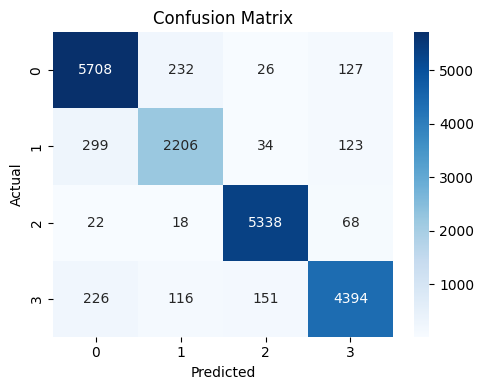

In [ ]:
# validation data evaluation
y_pred = lr_model_extreme.predict(X_val_tfidf_extreme)

accuracy = accuracy_score(y_val, y_pred)
print("Accuracy:", accuracy)

f1 = f1_score(y_val, y_pred, average='macro')
print("F1-score (Macro):", f1)

print("Validation Classification Report of Logistic Regression Model with Extreme Preprocessing:\n")
print(classification_report(y_val, y_pred))


print("Validation Confusion Matrix of Logistic Regression Model with Extreme Preprocessing:\n")
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

Accuracy: 0.9024166666666666
F1-score (Macro): 0.9021520020236657
Test Classification Report of Logistic Regression Model with Extreme Preprocessing:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      3000
           1       0.92      0.84      0.87      3000
           2       0.95      0.98      0.96      3000
           3       0.91      0.90      0.91      3000

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000

Test Confusion Matrix of Logistic Regression Model with Extreme Preprocessing:



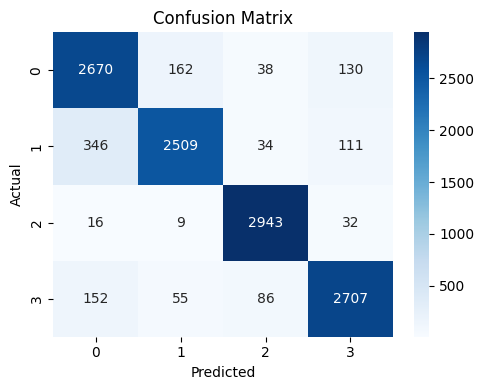

In [ ]:
# test data evaluation
y_pred = lr_model_extreme.predict(X_test_tfidf_extreme)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

f1 = f1_score(y_test, y_pred, average='macro')
print("F1-score (Macro):", f1)

print("Test Classification Report of Logistic Regression Model with Extreme Preprocessing:\n")
print(classification_report(y_test, y_pred))


print("Test Confusion Matrix of Logistic Regression Model with Extreme Preprocessing:\n")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Skipgram

In [ ]:
!pip install gensim
import gensim
from gensim.models import Word2Vec

In [ ]:
# skipgram model training
sentences = [sentence.lower().split() for sentence in X_train_extreme]

sg_model_extreme = Word2Vec(vector_size=100, window=5, sg=1, min_count=1)

sg_model_extreme.build_vocab(sentences)
sg_model_extreme.train(sentences, total_examples=len(sentences), epochs=10)

(18172522, 18423520)

In [ ]:
# word to vector conversion
import numpy as np

def sentence_to_vectors(text):
    words = text.lower().split()
    vectors = []

    for word in words:
        if word in sg_model_extreme.wv:
            vectors.append(sg_model_extreme.wv[word])
        else:
            vectors.append(np.zeros(sg_model_extreme.vector_size))
    return np.array(vectors)


X_train_vec_extreme = [sentence_to_vectors(s) for s in X_train_extreme]
X_val_vec_extreme = [sentence_to_vectors(s) for s in X_val_extreme]
X_test_vec_extreme  = [sentence_to_vectors(s) for s in X_test_extreme]

In [ ]:
# padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len = 50

X_train_vec_extreme = pad_sequences(X_train_vec_extreme, maxlen=max_len, padding='post', dtype='float32')
X_val_vec_extreme = pad_sequences(X_val_vec_extreme, maxlen=max_len, padding='post', dtype='float32')
X_test_vec_extreme  = pad_sequences(X_test_vec_extreme, maxlen=max_len, padding='post', dtype='float32')

In [ ]:
X_train_vec_extreme.shape

(76352, 50, 100)

# DNN

In [ ]:
dnn_model_extreme = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_tfidf_extreme.shape[1],)),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(4, activation="softmax")
])

dnn_model_extreme.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

dnn_model_extreme.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │     6,546,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,028 (25.01 MB)

 Trainable params: 6,557,028 (25.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

dnn_history_extreme = dnn_model_extreme.fit(
    X_train_tfidf_extreme, y_train_oh,
    epochs=8,
    batch_size=32,
    validation_data=(X_val_tfidf_extreme, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 273s 111ms/step - accuracy: 0.8939 - loss: 0.3141 - val_accuracy: 0.9253 - val_loss: 0.2219
Epoch 2/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 38s 16ms/step - accuracy: 0.9480 - loss: 0.1565 - val_accuracy: 0.9307 - val_loss: 0.2180
Epoch 3/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9652 - loss: 0.1041 - val_accuracy: 0.9311 - val_loss: 0.2386
Epoch 4/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9751 - loss: 0.0726 - val_accuracy: 0.9312 - val_loss: 0.2705
Epoch 5/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9811 - loss: 0.0551 - val_accuracy: 0.9293 - val_loss: 0.2924


597/597 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step
Validation Accuracy: 0.9307418273260687
Validation F1-score (Macro): 0.92075754824962
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6093
           1       0.84      0.87      0.85      2662
           2       0.96      0.99      0.97      5446
           3       0.95      0.90      0.92      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



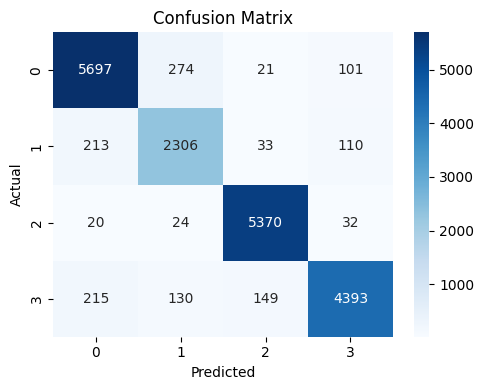

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = dnn_model_extreme.predict(X_val_tfidf_extreme)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Test Accuracy: 0.9146666666666666
Test F1-score (Macro): 0.9143833281528824
Test Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      3000
           1       0.91      0.87      0.89      3000
           2       0.95      0.99      0.97      3000
           3       0.92      0.91      0.92      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000

Test Confusion Matrix:



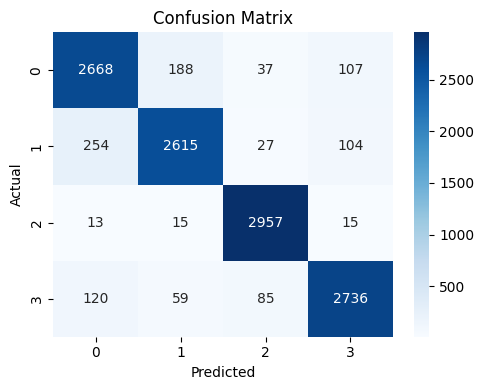

In [ ]:
# Test Data Evaluation
y_test_pred_prob = dnn_model_extreme.predict(X_test_tfidf_extreme)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# SimpleRNN

In [ ]:
from tensorflow.keras.layers import SimpleRNN, Input

# Get dimensions from your data
max_len = X_train_vec_extreme.shape[1]
embedding_dim = X_train_vec_extreme.shape[2]

simple_rnn_model_extreme = Sequential([
    SimpleRNN(96, input_shape=(max_len, embedding_dim)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

simple_rnn_model_extreme.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

simple_rnn_model_extreme.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 96)             │        18,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,148 (86.52 KB)

 Trainable params: 22,148 (86.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

simple_rnn_history_extreme = simple_rnn_model_extreme.fit(
    X_train_vec_extreme, y_train_oh,
    epochs=6,
    batch_size=128,
    validation_data = (X_val_vec_extreme, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/6
597/597 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7548 - loss: 0.6901 - val_accuracy: 0.6999 - val_loss: 0.7433
Epoch 2/6
597/597 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3760 - loss: 1.2579 - val_accuracy: 0.3192 - val_loss: 1.3532
Epoch 3/6
597/597 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3122 - loss: 1.3544 - val_accuracy: 0.3192 - val_loss: 1.3490
Epoch 4/6
597/597 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3180 - loss: 1.3516 - val_accuracy: 0.3192 - val_loss: 1.3472


597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Validation Accuracy: 0.6999161777032691
Validation F1-score (Macro): 0.5670871147282124
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.62      0.94      0.75      6093
           1       0.88      0.00      0.01      2662
           2       0.95      0.65      0.78      5446
           3       0.66      0.84      0.74      4887

    accuracy                           0.70     19088
   macro avg       0.78      0.61      0.57     19088
weighted avg       0.76      0.70      0.65     19088

Validation Confusion Matrix:



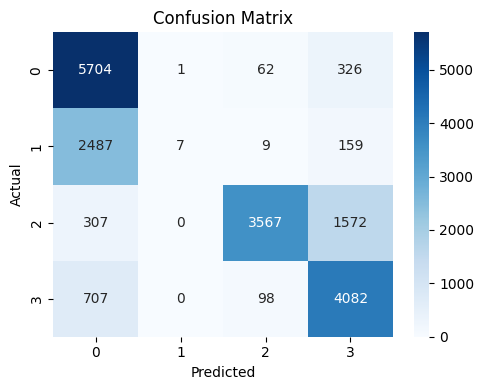

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = simple_rnn_model_extreme.predict(X_val_vec_extreme)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Test Accuracy: 0.6059166666666667
Test F1-score (Macro): 0.532433775793145
Test Classification Report:

              precision    recall  f1-score   support

           0       0.45      0.93      0.61      3000
           1       0.50      0.00      0.00      3000
           2       0.95      0.65      0.78      3000
           3       0.67      0.84      0.75      3000

    accuracy                           0.61     12000
   macro avg       0.64      0.61      0.53     12000
weighted avg       0.64      0.61      0.53     12000

Test Confusion Matrix:



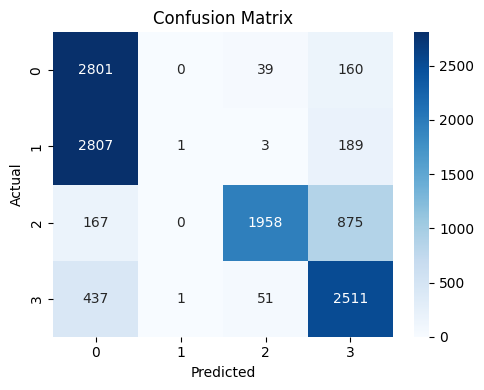

In [ ]:
# Test Data Evaluation
y_test_pred_prob = simple_rnn_model_extreme.predict(X_test_vec_extreme)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# LSTM

In [ ]:
from tensorflow.keras.layers import LSTM

max_len = X_train_vec_extreme.shape[1]
embedding_dim = X_train_vec_extreme.shape[2]

lstm_model_extreme = Sequential([
    LSTM(128, input_shape=(max_len, embedding_dim)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

lstm_model_extreme.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model_extreme.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,276 (524.52 KB)

 Trainable params: 134,276 (524.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )


history_lstm_extreme = lstm_model_extreme.fit(
    X_train_vec_extreme, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_vec_extreme, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.8587 - loss: 0.4289 - val_accuracy: 0.8950 - val_loss: 0.3228
Epoch 2/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9023 - loss: 0.3026 - val_accuracy: 0.9074 - val_loss: 0.2814
Epoch 3/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9080 - loss: 0.2770 - val_accuracy: 0.9137 - val_loss: 0.2625
Epoch 4/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9145 - loss: 0.2563 - val_accuracy: 0.9051 - val_loss: 0.2704
Epoch 5/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9205 - loss: 0.2362 - val_accuracy: 0.9202 - val_loss: 0.2419
Epoch 6/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9261 - loss: 0.2184 - val_accuracy: 0.9168 - val_loss: 0.2402
Epoch 7/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9313 - loss: 0.2037 - val_accuracy: 0.9222 - val_loss: 0.2321
Epoch 8/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.9357 - loss: 0

597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Validation Accuracy: 0.9279128248113998
Validation F1-score (Macro): 0.9179559076868137
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      6093
           1       0.84      0.86      0.85      2662
           2       0.97      0.99      0.98      5446
           3       0.93      0.92      0.92      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



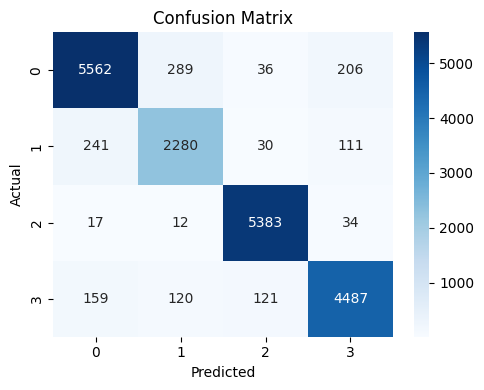

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = lstm_model_extreme.predict(X_val_vec_extreme)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Test Accuracy: 0.9128333333333334
Test F1-score (Macro): 0.9124437838478173
Test Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.87      0.88      3000
           1       0.91      0.87      0.88      3000
           2       0.96      0.99      0.97      3000
           3       0.90      0.93      0.91      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000

Test Confusion Matrix:



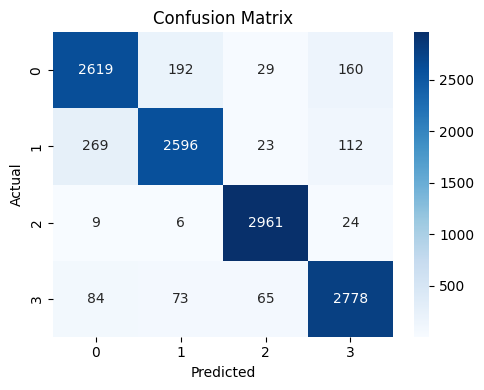

In [ ]:
# Test Data Evaluation
y_test_pred_prob = lstm_model_extreme.predict(X_test_vec_extreme)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# GRU

In [ ]:
from tensorflow.keras.layers import GRU

max_len = X_train_vec_extreme.shape[1]
embedding_dim = X_train_vec_extreme.shape[2]

gru_model_extreme = Sequential([
    GRU(64, input_shape=(max_len, embedding_dim)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

gru_model_extreme.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

gru_model_extreme.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,292 (141.77 KB)

 Trainable params: 36,292 (141.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_gru_extreme = gru_model_extreme.fit(
    X_train_vec_extreme, y_train_oh,
    epochs=6,
    batch_size=64,
    validation_data=(X_val_vec_extreme, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.7628 - loss: 0.5696 - val_accuracy: 0.9046 - val_loss: 0.3034
Epoch 2/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9048 - loss: 0.2924 - val_accuracy: 0.9099 - val_loss: 0.2764
Epoch 3/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9113 - loss: 0.2651 - val_accuracy: 0.9142 - val_loss: 0.2615
Epoch 4/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9153 - loss: 0.2473 - val_accuracy: 0.9151 - val_loss: 0.2538
Epoch 5/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9192 - loss: 0.2329 - val_accuracy: 0.9163 - val_loss: 0.2455
Epoch 6/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9232 - loss: 0.2219 - val_accuracy: 0.9233 - val_loss: 0.2314


597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Validation Accuracy: 0.9232502095557418
Validation F1-score (Macro): 0.9121101455602518
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.91      6093
           1       0.85      0.82      0.84      2662
           2       0.97      0.98      0.97      5446
           3       0.94      0.90      0.92      4887

    accuracy                           0.92     19088
   macro avg       0.92      0.91      0.91     19088
weighted avg       0.92      0.92      0.92     19088

Validation Confusion Matrix:



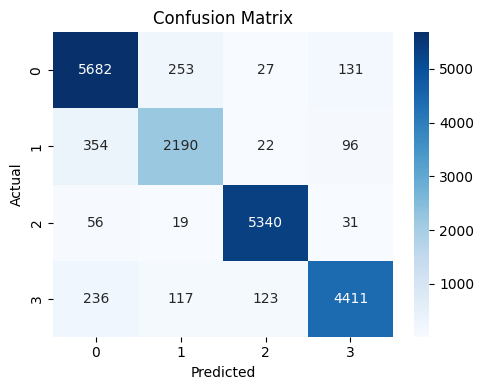

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = gru_model_extreme.predict(X_val_vec_extreme)

y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Test Accuracy: 0.90625
Test F1-score (Macro): 0.9061202139313325
Test Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      3000
           1       0.92      0.82      0.87      3000
           2       0.96      0.98      0.97      3000
           3       0.92      0.91      0.91      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000

Test Confusion Matrix:



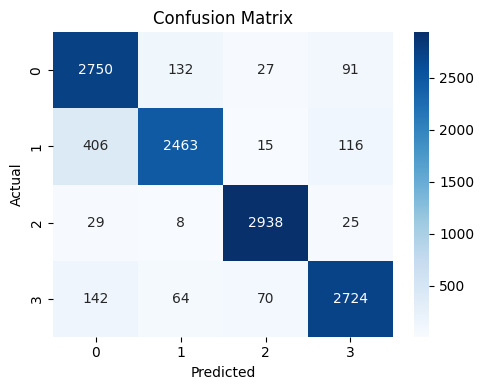

In [ ]:
# Test Data Evaluation
y_test_pred_prob = gru_model_extreme.predict(X_test_vec_extreme)

y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Bidirectional SimpleRNN

In [ ]:
from tensorflow.keras.layers import Bidirectional, SimpleRNN

max_len = X_train_vec_extreme.shape[1]
embedding_dim = X_train_vec_extreme.shape[2]

bidirectional_simple_rnn_model_extreme = Sequential([
    Input(shape=(max_len, embedding_dim)), # Explicit Input layer
    Bidirectional(SimpleRNN(128, input_shape=(max_len, embedding_dim))),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

bidirectional_simple_rnn_model_extreme.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

bidirectional_simple_rnn_model_extreme.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 256)            │        58,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,036 (359.52 KB)

 Trainable params: 92,036 (359.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_bidirectional_simple_rnn_extreme = bidirectional_simple_rnn_model_extreme.fit(
    X_train_vec_extreme, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_vec_extreme, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - accuracy: 0.8698 - loss: 0.3922 - val_accuracy: 0.8743 - val_loss: 0.3609
Epoch 2/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.8818 - loss: 0.3600 - val_accuracy: 0.8917 - val_loss: 0.3312
Epoch 3/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.8848 - loss: 0.3517 - val_accuracy: 0.8743 - val_loss: 0.3758
Epoch 4/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.8916 - loss: 0.3256 - val_accuracy: 0.8956 - val_loss: 0.3274
Epoch 5/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.8902 - loss: 0.3274 - val_accuracy: 0.8554 - val_loss: 0.4182
Epoch 6/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.8862 - loss: 0.3325 - val_accuracy: 0.8978 - val_loss: 0.3110
Epoch 7/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.8940 - loss: 0.3110 - val_accuracy: 0.8908 - val_loss: 0.3275
Epoch 8/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.8958 -

597/597 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Validation Accuracy: 0.8977891869237217
Validation F1-score (Macro): 0.8846169670310092
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      6093
           1       0.81      0.79      0.80      2662
           2       0.94      0.98      0.96      5446
           3       0.93      0.87      0.90      4887

    accuracy                           0.90     19088
   macro avg       0.89      0.88      0.88     19088
weighted avg       0.90      0.90      0.90     19088

Validation Confusion Matrix:



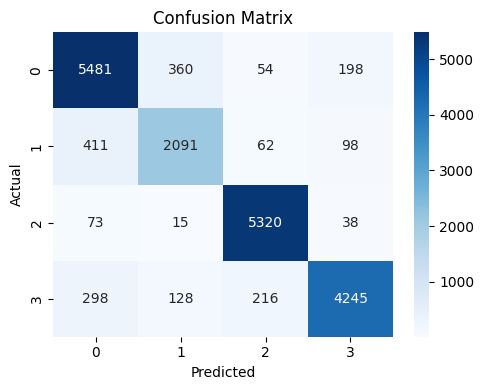

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = bidirectional_simple_rnn_model_extreme.predict(X_val_vec_extreme)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Test Accuracy: 0.8850833333333333
Test F1-score (Macro): 0.8845485983356585
Test Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.89      0.85      3000
           1       0.90      0.79      0.84      3000
           2       0.93      0.98      0.95      3000
           3       0.91      0.88      0.89      3000

    accuracy                           0.89     12000
   macro avg       0.89      0.89      0.88     12000
weighted avg       0.89      0.89      0.88     12000

Test Confusion Matrix:



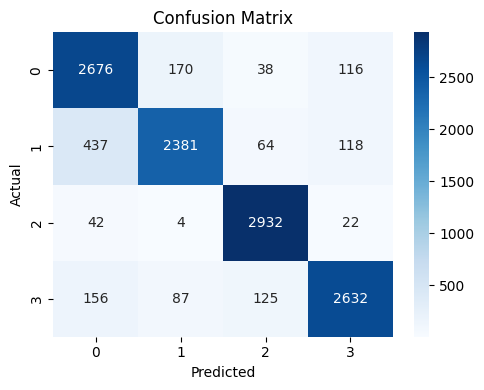

In [ ]:
# Test Data Evaluation
y_test_pred_prob = bidirectional_simple_rnn_model_extreme.predict(X_test_vec_extreme)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Bidirectional LSTM

In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional, Input

max_len = X_train_vec_extreme.shape[1]
embedding_dim = X_train_vec_extreme.shape[2]

bidirectional_lstm_model_extreme = Sequential([
    Input(shape=(max_len, embedding_dim)), # Explicit Input layer
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

bidirectional_lstm_model_extreme.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bidirectional_lstm_model_extreme.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,996 (363.27 KB)

 Trainable params: 92,996 (363.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_bidirectional_lstm_extreme = bidirectional_lstm_model_extreme.fit(
    X_train_vec_extreme, y_train_oh,
    epochs=6,
    batch_size=64,
    validation_data= (X_val_vec_extreme, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8899 - loss: 0.3267 - val_accuracy: 0.9060 - val_loss: 0.2768
Epoch 2/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9074 - loss: 0.2675 - val_accuracy: 0.9122 - val_loss: 0.2537
Epoch 3/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9137 - loss: 0.2459 - val_accuracy: 0.9152 - val_loss: 0.2482
Epoch 4/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9208 - loss: 0.2292 - val_accuracy: 0.9182 - val_loss: 0.2375
Epoch 5/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9233 - loss: 0.2184 - val_accuracy: 0.9185 - val_loss: 0.2334
Epoch 6/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9272 - loss: 0.2061 - val_accuracy: 0.9195 - val_loss: 0.2356


597/597 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Validation Accuracy: 0.918535205364627
Validation F1-score (Macro): 0.9085220831211851
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      6093
           1       0.79      0.88      0.83      2662
           2       0.96      0.99      0.97      5446
           3       0.94      0.90      0.92      4887

    accuracy                           0.92     19088
   macro avg       0.90      0.91      0.91     19088
weighted avg       0.92      0.92      0.92     19088

Validation Confusion Matrix:



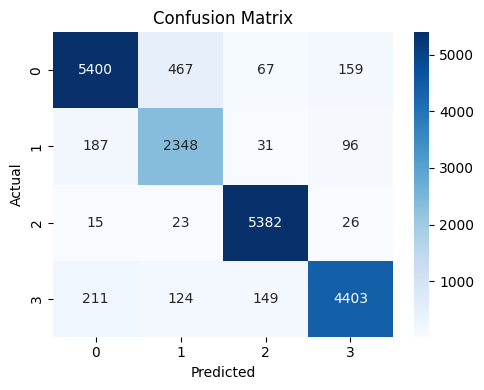

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = bidirectional_lstm_model_extreme.predict(X_val_vec_extreme)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Test Accuracy: 0.9156666666666666
Test F1-score (Macro): 0.9153767134598356
Test Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      3000
           1       0.90      0.88      0.89      3000
           2       0.95      0.99      0.97      3000
           3       0.93      0.91      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000

Test Confusion Matrix:



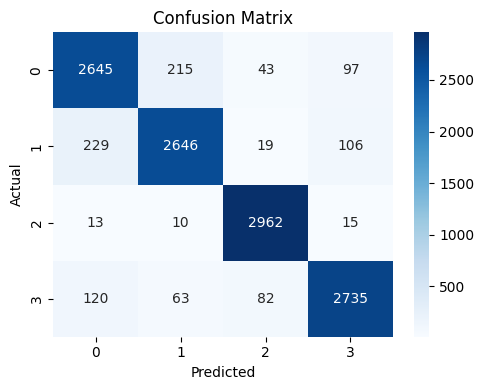

In [ ]:
# Test Data Evaluation
y_test_pred_prob = bidirectional_lstm_model_extreme.predict(X_test_vec_extreme)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# **Bidirectional GRU**

In [ ]:
from tensorflow.keras.layers import GRU, Bidirectional, Input

max_len = X_train_vec_extreme.shape[1]
embedding_dim = X_train_vec_extreme.shape[2]

bidirectional_gru_model_extreme = Sequential([
    Input(shape=(max_len, embedding_dim)), # Explicit Input layer
    Bidirectional(GRU(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

bidirectional_gru_model_extreme.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bidirectional_gru_model_extreme.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_5 (Bidirectional) │ (None, 128)            │        63,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,260 (282.27 KB)

 Trainable params: 72,260 (282.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_bidirectional_gru_extreme = bidirectional_gru_model_extreme.fit(
    X_train_vec_extreme, y_train_oh,
    epochs=6,
    batch_size=64,
    validation_data = (X_val_vec_extreme, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8843 - loss: 0.3327 - val_accuracy: 0.9073 - val_loss: 0.2742
Epoch 2/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9084 - loss: 0.2665 - val_accuracy: 0.9120 - val_loss: 0.2574
Epoch 3/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9128 - loss: 0.2504 - val_accuracy: 0.9155 - val_loss: 0.2515
Epoch 4/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9172 - loss: 0.2370 - val_accuracy: 0.9166 - val_loss: 0.2419
Epoch 5/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9215 - loss: 0.2247 - val_accuracy: 0.9209 - val_loss: 0.2341
Epoch 6/6
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9252 - loss: 0.2135 - val_accuracy: 0.9224 - val_loss: 0.2291


597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Validation Accuracy: 0.9224119865884325
Validation F1-score (Macro): 0.9111965177971928
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.91      6093
           1       0.83      0.84      0.83      2662
           2       0.96      0.99      0.97      5446
           3       0.96      0.89      0.92      4887

    accuracy                           0.92     19088
   macro avg       0.91      0.91      0.91     19088
weighted avg       0.92      0.92      0.92     19088

Validation Confusion Matrix:



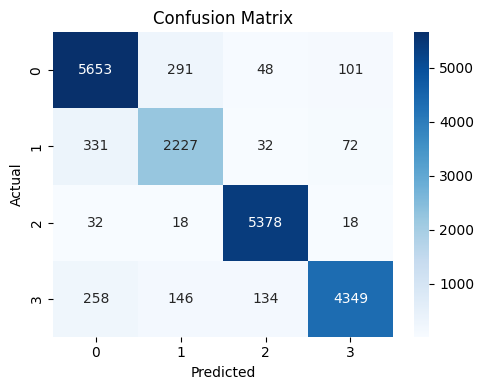

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = bidirectional_gru_model_extreme.predict(X_val_vec_extreme)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Test Accuracy: 0.9093333333333333
Test F1-score (Macro): 0.9092524824121829
Test Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      3000
           1       0.92      0.84      0.88      3000
           2       0.95      0.99      0.97      3000
           3       0.94      0.90      0.92      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000

Test Confusion Matrix:



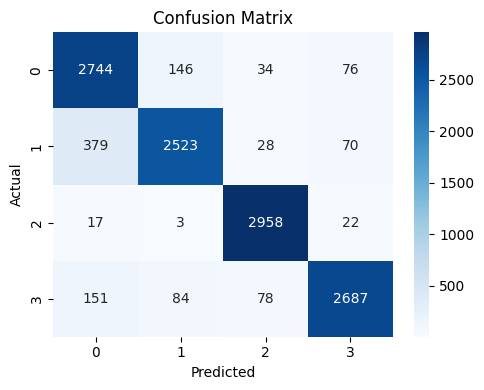

In [ ]:
# Test Data Evaluation
y_test_pred_prob = bidirectional_gru_model_extreme.predict(X_test_vec_extreme)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()